<!--
This notebook presents the usage of the `ve_run` command to run the example data.
We want the notebook to be dynamic - so that updates to the model get included
automatically but we don't want to expose a new user to a load of tricky code from
running the model within the notebook.

So - the notebook uses `code-block` entries to show the code and then contains
`code-cell` blocks with 'remove-cell' tags to run the actual model building in the
background. This cells will only execute successfully on systems with a bash shell.
-->

# Using the Virtual Ecosystem

This page provides a brief demonstration of the Virtual Ecosystem model in operation.
Once you have [installed the Virtual Ecosystem](./installing_ve.md), you should be able
to replicate this example on your own computer using the commands below.

## Example model data

The demonstration requires an [installation of the example data](./example_data.md)
provided with the Virtual Ecosystem package. If you have previously attempted to run
this example then the simulation will refuse to overwrite existing output files. You can
either:

* delete the existing example data folder and reinstall it,
* create a fresh installation using a different location, or
* create and use a new output directory with the existing example data folder.

It is worth re-reading the [example data page](./example_data.md) to get an overview of
the directory structure and the configuration and data files.

In [60]:
%%bash
# Remove any existing VE data directory in the execution directory
if [ -d ve_example ]; then
  rm -r ve_example
fi

export PYTHONUNBUFFERED=1
ve_run --install-example .

Example directory created at:
ve_example


## The `ve_run` command

You've already used this command to install the example data but most of the options to
the `ve_run` command are used to run the simulation. The `--help` option can be used to
show the various arguments that can be used to set how a model runs:

`````{tab-set}
:sync-group: operating_system

````{tab-item} macOS/Linux
:sync: macoslinux

```{code-block} shell
ve_run --help
```
````

````{tab-item} Windows (CMD)
:sync: windows-cmd

```{code-block} shell
ve_run --help
```
````

````{tab-item} Windows (Powershell)
:sync: windows-powershell

```{code-block} powershell
ve_run --help
```
````


`````

In [61]:
%%bash
# Code to actually get the command line help
export PYTHONUNBUFFERED=1
ve_run --help

usage: ve_run [-h] [--version] [--install-example INSTALL_EXAMPLE]
              [-o OUTPATH] [-c CLI_CONFIG] [--logfile LOGFILE] [-q]
              [cfg_paths ...]

Configure and run a Virtual Ecosystem simulation.

This program sets up and runs a Virtual Ecosystem simulation. The program expects
to be provided with paths to TOML formatted configuration files for the simulation.
The configuration is modular: a directory path can be used to add all TOML
configuration files in the directory, or individual file paths can be used to select
specific combinations of configuration files. These are combined and validated and
then used to initialise and run the model.

As an alternative to providing configuration paths, the `--install-example` option
allows users to provide a location where a simple example set of datasets and
configuration files provided with the Virtual Ecosystem package can be installed.
This option will create a `ve_example` directory in the location, and users can
examine

## Running the example model

The code below runs a simulation using the example data. The command uses the command
line options to set three things:

1. It points to the files in `config` directory that should be used configure the model.
   N.B. this directory contains configuration for all possible model combinations so
   providing just the `config` directory as a path will result in an invalid
   configuration.

1. It sets the output directory to be used by the simulation to `out`. You could create
   a new output directory (e.g. `out_test_2`) and change this to run a new simulation
   using the existing data.

1. It redirects the model logging to a file in the output directory, rather than
   printing it all to screen.

When the detailed logging is redirected to a file, the command generates a short
progress report to show the model running. This can be made shorter or completely muted
by using the `-q` argument: repeat the argument to remove more details (e.g. `-qq` or
`-qqq`).

```{warning}
If the path provided for the log points to a file that already exists the detailed
logging is added to the end of the file rather than creating a new file. We would
recommend creating a new logfile for each simulation as reusing files in this way can
create confusion.
```

In the example code below, the ve_example folder has been previously installed under the
directory /tmp/

`````{tab-set}
:sync-group: operating_system

````{tab-item} macOS/Linux
:sync: macoslinux

```{code-block} shell
ve_run /tmp/ve_example/config/data_config.toml \
    /tmp/ve_example/config/abiotic_config.toml \
    /tmp/ve_example/config/animal_config.toml \
    /tmp/ve_example/config/hydrology_config.toml \
    /tmp/ve_example/config/litter_config.toml \
    /tmp/ve_example/config/plant_config.toml \
    /tmp/ve_example/config/soil_config.toml \
    --out /tmp/ve_example/out \
    --logfile /tmp/ve_example/out/logfile.log
```
````

````{tab-item} Windows (CMD)
:sync: windows-cmd

```{code-block} shell
ve_run C:\tmp\ve_example\config\data_config.toml ^
    C:\tmp\ve_example\config\abiotic_config.toml ^
    C:\tmp\ve_example\config\animal_config.toml ^
    C:\tmp\ve_example\config\hydrology_config.toml ^
    C:\tmp\ve_example\config\litter_config.toml ^
    C:\tmp\ve_example\config\plant_config.toml ^
    C:\tmp\ve_example\config\soil_config.toml ^
    --out C:\tmp\ve_example\out ^
    --logfile C:\tmp\ve_example\logfile.log
```
````

````{tab-item} Windows (Powershell)
:sync: windows-powershell

```{code-block} powershell
ve_run C:\tmp\ve_example\config\data_config.toml `
    C:\tmp\ve_example\config\abiotic_config.toml `
    C:\tmp\ve_example\config\animal_config.toml `
    C:\tmp\ve_example\config\hydrology_config.toml `
    C:\tmp\ve_example\config\litter_config.toml `
    C:\tmp\ve_example\config\plant_config.toml `
    C:\tmp\ve_example\config\soil_config.toml `
    --out C:\tmp\ve_example\out `
    --logfile C:\tmp\ve_example\logfile.log
```
````

`````

In [ ]:
%%script bash --err discarded_stderr
# Code to actually run the model in bash in the local directory, using the cell magic
# to swallow any standard error output warnings.
export PYTHONUNBUFFERED=1
ve_run ve_example/config/data_config.toml ve_example/config/abiotic_config.toml \
    ve_example/config/animal_config.toml ve_example/config/hydrology_config.toml \
    ve_example/config/litter_config.toml ve_example/config/plant_config.toml \
    ve_example/config/soil_config.toml --out ve_example/out \
    --logfile ve_example/out/logfile.log

# Retain a truncated chunk of the log file locally to use within include directive
(head -n 20; echo "--- many lines omitted ---"; tail -n 20;) < \
ve_example/out/logfile.log > truncated_logfile.log



Starting Virtual Ecosystem simulation.
Logging to: ve_example/out/logfile.log
* Loading configuration
* Saved compiled configuration: ve_example/out/ve_full_model_configuration.toml
* Built core model components
* Initial data loaded
* Models initialised: soil, hydrology, abiotic, animal, litter, plants
* Saved model initial state
* Starting simulation
100%|██████████| 24/24 [00:50<00:00,  2.12s/it]
* Simulation completed
* Merged time series data
* Saved final model state
Virtual Ecosystem run complete.


The log file is very long and shows the step by step process of running the model - it
is primarily used for diagnosing problems with the model. You can view a sample of the
contents in the dropdown below:

````{dropdown} Partial log output
```{literalinclude} truncated_logfile.log
```
````

## Looking at the results

The Virtual Ecosystem writes out a number of data files:

* `initial_state.nc`: A single compiled file of the initial input data.
* `all_continuous_data.nc`: An optional record of time series data of the variables
  updated at each time step.
* `final_state.nc`: The model data state at the end of the final step.

These files are written to the standard NetCDF data file format: below, we use the
`xarray` and `matplotlib` Python packages to load and visualise this data. You may need
to install these to replicate these outputs on your own computer.

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import xarray

# Load the generated data files
initial_state = xarray.load_dataset("ve_example/out/initial_state.nc")
continuous_data = xarray.load_dataset("ve_example/out/all_continuous_data.nc")
final_state = xarray.load_dataset("ve_example/out/final_state.nc")

### Initial state and input data

The `initial_state.nc` file contains all of the data required to run the model. For some
variables - such as elevation and soil pH - this just provides the constant value for
each grid cell than will then be used throughout the simulation. For other variables -
such as the litter pool sizes - the values provided are initial values which wil be
updated as the simulation runs.  Finally, for some variables - such as precipitation and
temperature - a time series is provided which is used to that drive (or force) the
behaviour of the model through time.

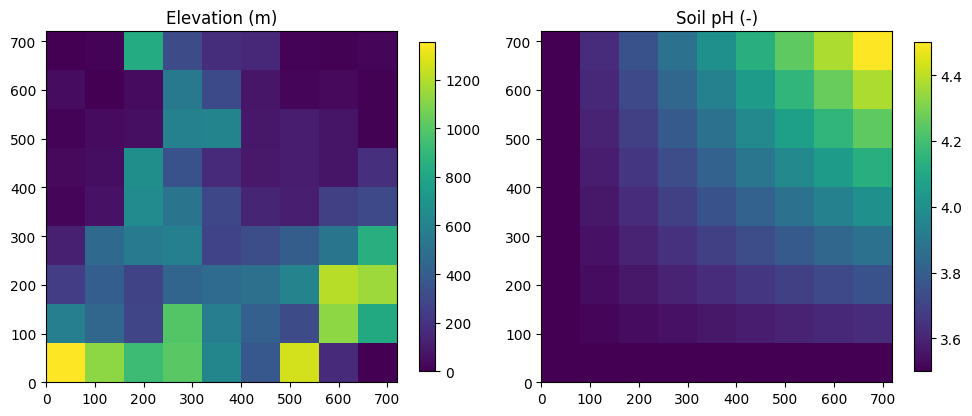

In [64]:
extent = [
    float(initial_state.x.min()),
    float(initial_state.x.max()),
    float(initial_state.y.min()),
    float(initial_state.y.max()),
]

# Make two side by side plots
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))

# Elevation
im1 = ax1.imshow(initial_state["elevation"].to_numpy().reshape((9, 9)), extent=extent)
ax1.set_title("Elevation (m)")
fig.colorbar(im1, ax=ax1, shrink=0.7)

# Initial soil carbon
im2 = ax2.imshow(initial_state["pH"].to_numpy().reshape((9, 9)), extent=extent)
ax2.set_title("Soil pH (-)")
fig.colorbar(im2, ax=ax2, shrink=0.7)

plt.tight_layout()

For some variables, it may be useful to visualise spatial structure in 3 dimensions.
The obvious candidate is elevation.

In [65]:
# Extract the elevation data for a 3D plot
top = initial_state["elevation"].to_numpy()
x = continuous_data["x"].to_numpy()
y = continuous_data["y"].to_numpy()
bottom = np.zeros_like(top)
width = depth = 90

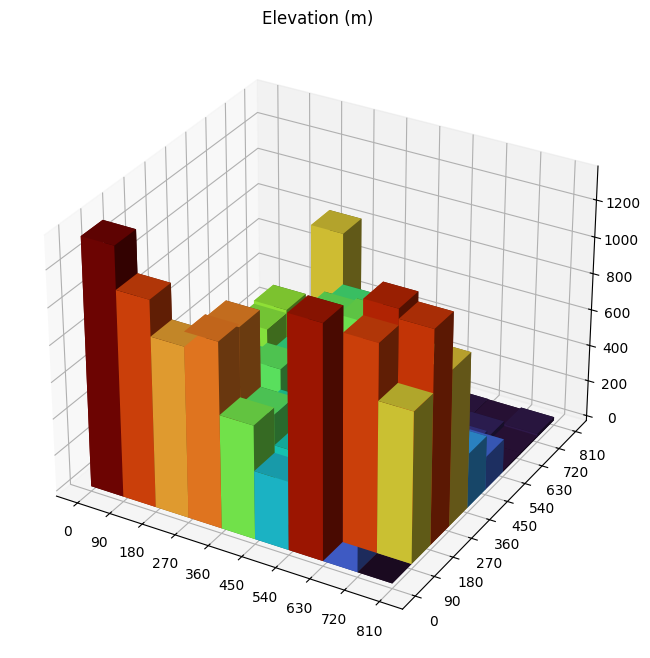

In [66]:
# Make a 3D barplot of the elevation
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection="3d")
colors = plt.cm.turbo(top.flatten() / float(top.max()))

poly = ax.bar3d(x, y, bottom, width, depth, top, shade=True, color=colors)
ax.set_title("Elevation (m)")

cell_bounds = range(0, 811, 90)
ax.set_xticks(cell_bounds)
_ = ax.set_yticks(cell_bounds)

For other variables, such as air temperature and precipitation, the initial data
also provides time series data at reference height that are used to force the
simulation across the configured time period.

In [67]:
initial_state

<xarray.Dataset> Size: 453kB
Dimensions:                               (cell_id: 81, time_index: 24, pft: 2,
                                           element: 3, layers: 14,
                                           community_id: 81,
                                           functional_group_id: 15,
                                           groundwater_layers: 2, dim_0: 81)
Coordinates:
  * cell_id                               (cell_id) int64 648B 0 1 2 ... 79 80
  * time_index                            (time_index) int64 192B 0 1 ... 22 23
  * pft                                   (pft) <U9 72B 'broadleaf' 'shrub'
  * element                               (element) <U1 12B 'C' 'N' 'P'
  * layers                                (layers) int64 112B 0 1 2 ... 11 12 13
  * community_id                          (community_id) int64 648B 0 1 ... 80
  * functional_group_id                   (functional_group_id) <U20 1kB 'car...
    x                                     (cell_id) int32 324B 0 90 ... 630 720
    y                                     (cell_id) int32 324B 720 720 ... 0 0
    layer_roles                           (layers) <U7 392B 'above' ... 'subs...
Dimensions without coordinates: groundwater_layers, dim_0
Data variables: (12/105)
    air_temperature_ref                   (cell_id, time_index) float64 16kB ...
    relative_humidity_ref                 (cell_id, time_index) float64 16kB ...
    atmospheric_pressure_ref              (cell_id, time_index) float64 16kB ...
    precipitation                         (cell_id, time_index) float64 16kB ...
    atmospheric_co2_ref                   (cell_id, time_index) float64 16kB ...
    mean_annual_temperature               (cell_id) float64 648B 23.0 ... 23.0
    ...                                    ...
    ecto_supply_limit_n                   (dim_0) float64 648B 0.0 0.0 ... 0.0
    ecto_supply_limit_p                   (dim_0) float64 648B 0.0 0.0 ... 0.0
    arbuscular_supply_limit_n             (dim_0) float64 648B 0.0 0.0 ... 0.0
    arbuscular_supply_limit_p             (dim_0) float64 648B 0.0 0.0 ... 0.0
    production_of_fungal_fruiting_bodies  (cell_id) float64 648B 0.0 0.0 ... 0.0
    timestamp                             (time_index) datetime64[ns] 192B 20...

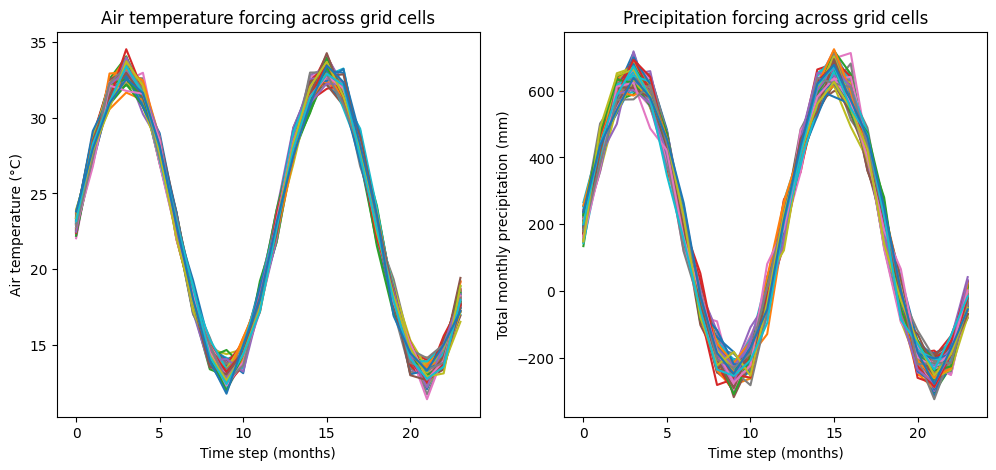

In [68]:
# Make two side by side plots
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Air temperature
ax1.plot(initial_state["time_index"], initial_state["air_temperature_ref"].T)
ax1.set_title("Air temperature forcing across grid cells")
ax1.set_ylabel("Air temperature (°C)")
ax1.set_xlabel("Time step (months)")

# Precipitation
ax2.plot(initial_state["time_index"], initial_state["precipitation"].T)
ax2.set_title("Precipitation forcing across grid cells")
ax2.set_ylabel("Total monthly precipitation (mm)")
_ = ax2.set_xlabel("Time step (months)")

### Model outputs
The main output of interest is the `all_continuous_data.nc` file, which contains
variables describing the change in the models through the simulation process. To keep
the size of this file down only variables updated by a model are included, which means
things like soil pH and input climatic data are not included. It also only contains the
values of variables after they have been updated, so the time series runs from the first
to final time step, i.e. the initial value of each variable is excluded. As the data
contained in this file has a time dimension, we can visualise it across time. This can
happen in a number of formats such as spatial grids, individual time series within grid
cells and as the three dimensional structure of the vertical layers within the
simulation. We describe these plotting processes below.

If you only want to compare the initial and final states of the model, you instead would
want to use the `final_state.nc` file which provides the full final state of the model,
i.e. is effectively the equivalent of `initial_state.nc` for the final time step (see
above for plotting suggestions).

```{warning}
At present when the Virtual Ecosystem reads in netCDF data it flips it (i.e. the
spatial `x` dimension becomes the `y` dimension and vice versa). This doesn't affect the
simlation, but does need to be corrected for when analysing the spatial outputs, which
will be flipped.
```

#### Spatial data

Using the soil carbon  held as **mineral-associated organic matter** as an example:

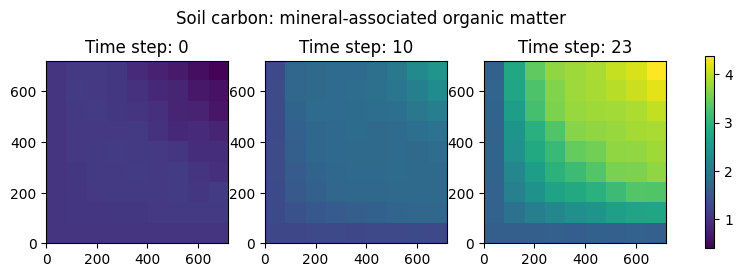

In [69]:
# Make three side by side plots
fig, axes = plt.subplots(ncols=3, figsize=(10, 5))

# Plot start and end MAOM
val_min = continuous_data["soil_c_pool_maom"].min()
val_max = continuous_data["soil_c_pool_maom"].max()

# Plot 3 time slices
for idx, ax in zip([0, 10, 23], axes):
    im = ax.imshow(
        continuous_data["soil_c_pool_maom"][idx, :].to_numpy().reshape((9, 9)),
        extent=extent,
        vmax=val_max,
        vmin=val_min,
    )
    ax.set_title(f"Time step: {idx}")

fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.5)
_ = plt.suptitle("Soil carbon: mineral-associated organic matter", y=0.78, x=0.45)

#### Temporal data

The plot below shows the **mineral-associated organic matter** data as a time series
showing the values in each cell across time.

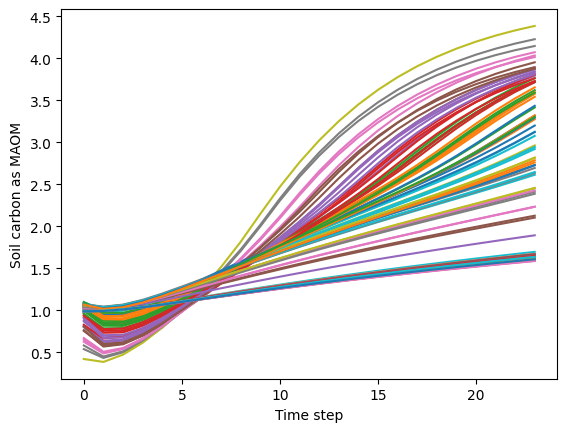

In [70]:
plt.plot(continuous_data["time_index"], continuous_data["soil_c_pool_maom"])
plt.xlabel("Time step")
_ = plt.ylabel("Soil carbon as MAOM")

#### Vertical structure

The Virtual Ecosystem creates a vertical dimension that is used to record canopy
heights and soil depths across the grid.

In [71]:
# Extract the x and y location of the grid cell centres and layer heights
# for all observations at a given time step.
time_index = 0

x_3d = (
    continuous_data["x"]
    .broadcast_like(continuous_data["layer_heights"][time_index])
    .to_numpy()
    .flatten()
    + 45
)
y_3d = (
    continuous_data["y"]
    .broadcast_like(continuous_data["layer_heights"][time_index])
    .to_numpy()
    .flatten()
    + 45
)
z_3d = continuous_data["layer_heights"][time_index].to_numpy().flatten()

# Extract the air temperature for those points to colour the 3D data.
temp_vals = continuous_data["air_temperature"][time_index].to_numpy().flatten()

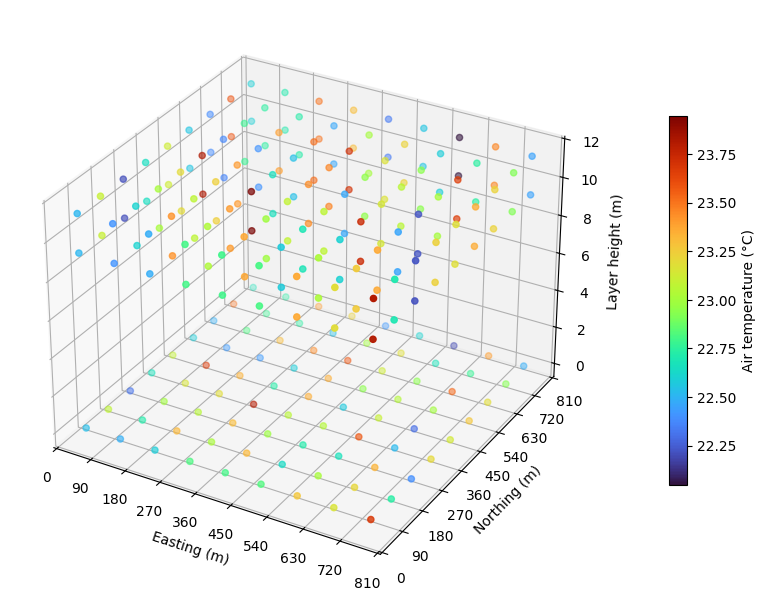

In [72]:
# Generate a 3 dimensional plot of layer heights showing temperature.

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection="3d")

cmap = plt.get_cmap("turbo")
paths = ax.scatter(x_3d, y_3d, z_3d, c=temp_vals, cmap=cmap)
fig.colorbar(
    paths,
    ax=ax,
    orientation="vertical",
    shrink=0.6,
    label="Air temperature (°C)",
    pad=0.1,
)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_zlabel("Layer height (m)")

ax.set_xticks(cell_bounds)
_ = ax.set_yticks(cell_bounds)

In [73]:
%%bash
# Remove the example directory
rm -r ve_example